In [38]:
# ── CELL 1: Import Libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
# ── CELL 2: Data Loading
data = fetch_openml(name="diabetes", version=1, as_frame=True, parser="auto")

X = data.data
y = (data.target == "tested_positive").astype(int)
y = pd.Series(y.values, name="target")

In [ ]:
# ── CELL 3: Data Exploration ──────────────────────────────────────────────────
print("Our Features (X):")
display(X.head())

print("\nOur Target (y):")
display(y.head())
display(X.info())
display(X.describe().T)

Our Features (X):


,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33



Our Target (y):


0    1
1    0
2    1
3    0
4    1
Name: target, dtype: int64

target
No Diabetes    500
Diabetes       268
Name: count, dtype: int64

Class percentages:
target
0    65.1
1    34.9
Name: proportion, dtype: float64


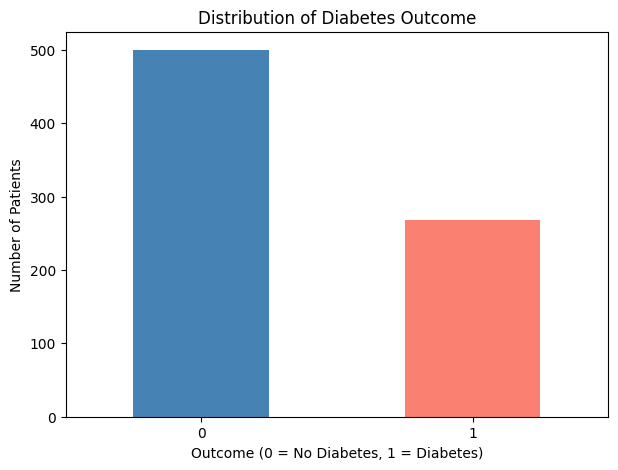

In [23]:
# ── CELL 4: Explore Target Variable ──────────────────────────────────────────
print(y.value_counts().sort_index().rename({0: "No Diabetes", 1: "Diabetes"}))

print("\nClass percentages:")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

plt.figure(figsize=(7, 5))
y.value_counts().sort_index().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# ── CELL 5: Feature / Target Separation

print("Features (X)/rows:", X.shape)
print("Target  (y)/columns :", y.shape)


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


None

,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
plas,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
pres,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
insu,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
mass,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
pedi,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


Features (X)/rows: (768, 8)
Target  (y)/columns : (768,)


In [ ]:
# ── CELL 6: Train / Test Split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Number of rows for training:", X_train.shape[0])
print("Number of rows for testing :", X_test.shape[0])

Number of rows for training: 614
Number of rows for testing : 154


In [26]:
# ── CELL 7: Standardize Features ─────────────────────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# ── CELL 8: Baseline Model ───────────────────────────────────────────────────
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_preds)
print(f"Baseline Model Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Model Accuracy: 64.29%


In [27]:
# ── CELL 9: Model Training ───────────────────────────────────────────────────
real_model = LogisticRegression(max_iter=1000)
real_model.fit(X_train, y_train)

# Class predictions
real_preds = real_model.predict(X_test)

# Probability predictions (needed for ROC-AUC)
real_probs = real_model.predict_proba(X_test)[:, 1]

In [28]:
# ── CELL 10: Predictions ──────────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Actual"    : y_test.values[:10],
    "Predicted" : real_preds[:10],
    "Correct?"  : ["✅" if a == p else "❌"
                   for a, p in zip(y_test.values[:10], real_preds[:10])]
})
display(comparison)

,Actual,Predicted,Correct?
0,0,0,✅
1,0,0,✅
2,0,0,✅
3,0,0,✅
4,0,0,✅
5,0,0,✅
6,0,0,✅
7,0,1,❌
8,0,1,❌
9,0,1,❌


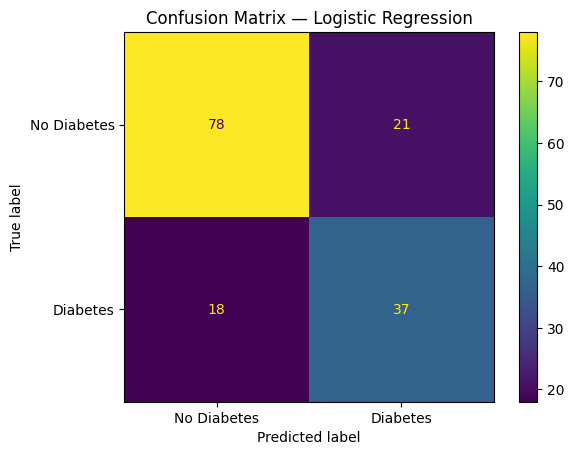

True Negative  (TN): 78
False Positive (FP): 21
False Negative (FN): 18
True Positive  (TP): 37


In [ ]:
# ── CELL 11: Confusion Matrix
cm = confusion_matrix(y_test, real_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)
disp.plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"True Negative  (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive  (TP): {TP}")

In [ ]:
# ── CELL 12: All Metrics 
accuracy  = accuracy_score(y_test, real_preds)
precision = precision_score(y_test, real_preds, zero_division=0)
recall    = recall_score(y_test, real_preds, zero_division=0)
f1        = f1_score(y_test, real_preds, zero_division=0)
roc_auc   = roc_auc_score(y_test, real_probs)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print(classification_report(y_test, real_preds,
                             target_names=["No Diabetes", "Diabetes"]))

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score" : [accuracy, precision, recall, f1, roc_auc]
})
display(metrics_df)

Accuracy : 0.7468
Precision: 0.6379
Recall   : 0.6727
F1-Score : 0.6549
ROC-AUC  : 0.8129

              precision    recall  f1-score   support

 No Diabetes       0.81      0.79      0.80        99
    Diabetes       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



,Metric,Score
0,Accuracy,0.746753
1,Precision,0.637931
2,Recall,0.672727
3,F1-Score,0.654867
4,ROC-AUC,0.812856


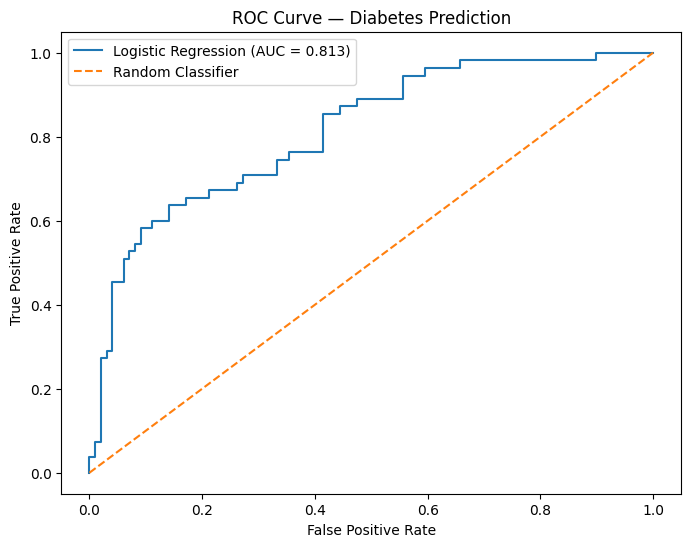

In [ ]:
# ── CELL 13: ROC Curve
fpr, tpr, _ = roc_curve(y_test, real_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Diabetes Prediction")
plt.legend()
plt.show()

In [39]:
# ── CELL 14: Why Accuracy Can Be Misleading ───────────────────────────────────
naive_predictions = np.zeros(len(y_test), dtype=int)

naive_accuracy  = accuracy_score(y_test, naive_predictions)
naive_precision = precision_score(y_test, naive_predictions, zero_division=0)
naive_recall    = recall_score(y_test, naive_predictions, zero_division=0)
naive_f1        = f1_score(y_test, naive_predictions, zero_division=0)

comparison_df = pd.DataFrame({
    "Metric"             : ["Accuracy", "Precision", "Recall", "F1-score"],
    "Logistic Regression": [accuracy, precision, recall, f1],
    "Naive Model"        : [naive_accuracy, naive_precision, naive_recall, naive_f1]
})
display(comparison_df)

,Metric,Logistic Regression,Naive Model
0,Accuracy,0.746753,0.642857
1,Precision,0.637931,0.000000
2,Recall,0.672727,0.000000
3,F1-score,0.654867,0.000000


In [ ]:
# ── CELL 15: Interpretation & Priority Metric ────────────────────────────────
print("""
RESULTS INTERPRETATION

Dataset: Pima Indians Diabetes Dataset
768 patients, 8 medical features, predicting Diabetes vs No Diabetes.

The model achieved 74.68% accuracy, which at first glance looks decent.
However, accuracy alone does not tell the full story. The dataset
has more No Diabetes patients (500) than Diabetes patients (268), meaning
a model that always guesses No Diabetes would still score around 65%
without ever detecting a single real case — which is exactly what the
naive baseline showed.

metrics:
- Precision (0.64): When the model said a patient has Diabetes,
  it was correct 64% of the time.

- Recall (0.67): The model caught 67% of all actual Diabetes cases,
  meaning it missed 33% of real patients.

- F1-Score (0.65): The balance between precision and recall is moderate,
  reflecting that neither is particularly strong.

- ROC-AUC (0.81): The model is reasonably good at separating diabetic
  from non-diabetic patients across different thresholds.

Which metric would I prioritize — and why?

Recall. In a medical screening context, the worst outcome is telling
a diabetic patient they are fine when they are not. That is a False
Negative — a missed diagnosis. A patient who is incorrectly told they
do not have diabetes will not seek treatment, which can lead to serious
health complications. A false alarm, on the other hand, simply means
the patient gets further testing. That is inconvenient but not harmful.

For this reason, Recall is the most important metric here. We want the
model to catch as many real Diabetes cases as possible, even if it
occasionally flags a healthy patient for follow-up.
""")


RESULTS INTERPRETATION

Dataset: Pima Indians Diabetes Dataset
768 patients, 8 medical features, predicting Diabetes vs No Diabetes.

The model achieved 74.68% accuracy, which at first glance looks decent.
However, accuracy alone does not tell the full story here. The dataset
has more No Diabetes patients (500) than Diabetes patients (268), meaning
a model that always guesses No Diabetes would still score around 65%
without ever detecting a single real case — which is exactly what the
naive baseline showed.

Looking deeper at the metrics:

- Precision (0.64): When the model said a patient has Diabetes,
  it was correct 64% of the time.

- Recall (0.67): The model caught 67% of all actual Diabetes cases,
  meaning it missed 33% of real patients.

- F1-Score (0.65): The balance between precision and recall is moderate,
  reflecting that neither is particularly strong.

- ROC-AUC (0.81): The model is reasonably good at separating diabetic
  from non-diabetic patients across different thr